# RLHF Distortion Simulation Suite

Simulation framework for studying **social welfare distortion** under **anonymous RLHF**,  
based on the framework in *Social Alignment via RLHF* (the paper).

---

## Pipeline Overview

```
DataGeneratingProcess
  └── agents θ_n ~ N(μ_g, Σ_g)     [multidimensional preference distribution]
  └── queries α_z ~ Uniform(S^{k-1}) [unit sphere]
  └── labels c ~ Bernoulli(σ(α_z^T θ_n))  [BTL model]
        ↓
AnonymousRLHF
  └── fit pooled multinomial logit → θ̂   [sklearn LogisticRegression]
        ↓
WelfareCalculator
  └── W_n^*(z)   = max(α_z^T θ_n, 0)          [idealized / argmax]
  └── W_n(θ; z)  = (α_z^T θ_n) · σ(α_z^T θ) [softmax, Eq. 6]
  └── compare: idealized | utilitarian-optimal θ̄ | RLHF θ̂
        ↓
AlignmentExternality
  └── IF estimate: Γ^m_{n,z} = ∇W_m^T J^{-1} s_{n,z}  (Eq. 12)
  └── Closed-form:  Γ_{n,z}^{social} = score_{n,z} · α_z^T η  (Eq. 16)
  └── Leave-one-out (LOO) ground truth
```

**Key objects from the paper:**
- θ_n ∈ R^k : agent preference vector  
- α_z ∈ R^k : query feature difference φ(x,y) − φ(x,y')  
- θ̄ = Σ_n w_n θ_n : utilitarian preference  
- θ̂ : RLHF-fitted parameter (pooled BTL MLE)  
- W_n(θ) = E_z[α_z^T θ_n · σ(α_z^T θ)] : agent n's deployment welfare (Eq. 6)  
- Γ^m_{n,z} : alignment externality — how agent n's data affects agent m's welfare (Def. 1)


In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.special import expit as sigmoid   # σ(t) = 1/(1+e^{-t})
from scipy.linalg import inv
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from dataclasses import dataclass
from typing import Optional
import warnings

try:
    from sklearn.exceptions import ConvergenceWarning
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
except ImportError:
    pass

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110

---
## 1. Data-Generating Process

**Model (linear preferences + BTL binary choice):**

- Individual utility: $u_n(y|x) = \phi(x,y)^\top \theta_n$ &emsp; (Eq. 3)
- Preference sampling: $\theta_n \sim \mathcal{N}(\mu_g, \Sigma_g)$ for group $g$, with $\Sigma_g = \Sigma_\text{base} + \delta_g I$  
- Query features: $\alpha_z = \phi(x,y) - \phi(x,y') \sim \text{Uniform}(S^{k-1})$  
- Binary label: $c \mid (n,z) \sim \text{Bernoulli}(\sigma(\alpha_z^\top \theta_n))$ &emsp; (BTL model, Eq. 1)

**Training vs. deployment query distributions** differ in general:  
$q_\text{train} \in \Delta_{N \times Z}$ (who labels which queries), $q_\text{dep}$ over $Z$ (real-world usage).  
Here we use independent samples from the same sphere distribution — a neutral baseline.

In [119]:
@dataclass
class DGPConfig:
    """All knobs for the synthetic data-generating process."""
    n_agents:        int   = 50
    k_dim:           int   = 8
    n_train_queries: int   = 500
    n_deploy_queries: int  = 200
    n_groups:        int   = 2
    group_weights:   Optional[np.ndarray] = None
    seed:            int   = 42
    base_cov_scale:  float = 1.0
    cov_delta:       float = 0.5
    mean_separation: float = 1.0        # legacy: offset group 1 along dim 0 only

    # ── Group mean structure ──────────────────────────────────────────────
    # mean_magnitude: magnitude of each group's mean along every dimension.
    # dim_agreement:  length-k array of ±1.
    #   +1 at dim d → both groups have positive mean along d (aligned)
    #   -1 at dim d → group 0 positive, group 1 negative (opposed)
    #   None         → fall back to legacy mean_separation (only dim 0 differs)
    #
    # With dim_agreement set, group means are:
    #   μ_0 = [+mean_magnitude, ..., +mean_magnitude]
    #   μ_1 = dim_agreement * mean_magnitude   (sign flipped on opposed dims)
    mean_magnitude: float = 1.0
    dim_agreement:  Optional[np.ndarray] = None

    # ── Distortion levers ─────────────────────────────────────────────────
    group_sizes:       Optional[list]        = None
    train_group_fracs: Optional[list]        = None
    train_query_mean:  Optional[np.ndarray]  = None
    deploy_query_mean: Optional[np.ndarray]  = None
    query_scale:       float                 = 1.0


class DataGeneratingProcess:
    """
    Generates:
      - Agent preference vectors  θ_n  ∈ R^k  (grouped Gaussians)
      - Query feature differences α_z  ∈ R^k  (Gaussian, not unit-normed)
      - Labels c | (n,z) ~ Bernoulli(σ(α_z^T θ_n))  [BTL model]
    """

    def __init__(self, cfg: DGPConfig):
        self.cfg = cfg
        self.rng = np.random.default_rng(cfg.seed)
        self._build()

    def _build(self):
        cfg = self.cfg
        k, N = cfg.k_dim, cfg.n_agents

        # ── Assign agents to groups ────────────────────────────────────
        if cfg.group_sizes is not None:
            assert sum(cfg.group_sizes) == N, "group_sizes must sum to n_agents"
            group_ids, start = [], 0
            for size in cfg.group_sizes:
                group_ids.append(np.arange(start, start + size))
                start += size
        else:
            group_ids = np.array_split(np.arange(N), cfg.n_groups)

        self.agent_groups = np.zeros(N, dtype=int)
        for g, ids in enumerate(group_ids):
            self.agent_groups[ids] = g
        self._group_ids = group_ids

        # ── Group means ────────────────────────────────────────────────
        if cfg.dim_agreement is not None:
            agreement = np.asarray(cfg.dim_agreement, dtype=float)  # (k,) of ±1
            assert len(agreement) == k, "dim_agreement must have length k_dim"
            # group 0: all positive;  group 1: sign flipped on opposed dims
            base_means = [
                np.full(k,  cfg.mean_magnitude),          # group 0
                agreement * cfg.mean_magnitude,            # group 1
            ]
        else:
            # Legacy: only dim 0 differs by mean_separation
            base_means = []
            for g in range(len(group_ids)):
                m = np.zeros(k)
                m[0] = g * cfg.mean_separation
                base_means.append(m)

        # ── Per-group preference distributions N(μ_g, Σ_g) ───────────
        thetas, self.group_means, self.group_covs = [], [], []
        for g, ids in enumerate(group_ids):
            mean_g = base_means[g] if g < len(base_means) else np.zeros(k)
            A_g    = self.rng.standard_normal((k, k))
            cov_g  = cfg.base_cov_scale * (A_g @ A_g.T) / k * (1 + g * cfg.cov_delta)
            thetas.append(self.rng.multivariate_normal(mean_g, cov_g, size=len(ids)))
            self.group_means.append(mean_g)
            self.group_covs.append(cov_g)

        self.theta = np.vstack(thetas)  # (N, k)

        # ── Social welfare weights ─────────────────────────────────────
        if cfg.group_weights is not None:
            self.w = cfg.group_weights / cfg.group_weights.sum()
        else:
            self.w = np.ones(N) / N

        self.theta_bar = (self.w[:, None] * self.theta).sum(0)  # (k,)

        # ── Query feature vectors: α_z ~ N(mean, scale²·I) ───────────
        self.alpha_train  = self._sample_queries(cfg.n_train_queries,
                                                  cfg.train_query_mean)
        self.alpha_deploy = self._sample_queries(cfg.n_deploy_queries,
                                                  cfg.deploy_query_mean)

        self._generate_training_data()

    def _sample_queries(self, n: int,
                        mean: Optional[np.ndarray] = None) -> np.ndarray:
        """α_z ~ N(mean, scale²·I). No normalization — preserves location."""
        raw = self.cfg.query_scale * self.rng.standard_normal((n, self.cfg.k_dim))
        if mean is not None:
            raw = raw + mean
        return raw

    def _generate_training_data(self):
        cfg   = self.cfg
        n_obs = cfg.n_train_queries
        N     = cfg.n_agents

        if cfg.train_group_fracs is not None:
            fracs = np.array(cfg.train_group_fracs, dtype=float)
            fracs = fracs / fracs.sum()
            p = np.zeros(N)
            for g, ids in enumerate(self._group_ids):
                p[ids] = fracs[g] / len(ids)
            p /= p.sum()
            agent_idx = self.rng.choice(N, size=n_obs, p=p)
        else:
            agent_idx = self.rng.integers(0, N, size=n_obs)

        query_idx = self.rng.integers(0, cfg.n_train_queries, size=n_obs)
        alpha_z   = self.alpha_train[query_idx]
        logits    = (alpha_z * self.theta[agent_idx]).sum(1)
        probs     = sigmoid(logits)
        labels    = self.rng.binomial(1, probs).astype(float)

        self.train_agent_idx   = agent_idx
        self.train_query_idx   = query_idx
        self.train_alpha       = alpha_z
        self.train_labels      = labels
        self.train_logits_true = logits

In [120]:
# ── Instantiate baseline DGP ──────────────────────────────────────────────
baseline_cfg = DGPConfig(
    n_agents=50, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
    n_groups=2, mean_separation=1.0, cov_delta=0.5, seed=42,
)
dgp = DataGeneratingProcess(baseline_cfg)

print(f"Agents: {baseline_cfg.n_agents}  |  k={baseline_cfg.k_dim}  |  Groups: {baseline_cfg.n_groups}")
print(f"Training obs: {baseline_cfg.n_train_queries}  |  Deploy queries: {baseline_cfg.n_deploy_queries}")
print(f"\nθ̄ (utilitarian mean): {dgp.theta_bar.round(3)}")
print(f"Group sizes: { {g: (dgp.agent_groups == g).sum() for g in range(baseline_cfg.n_groups)} }")
print(f"Per-group theta_n mean (dim 0 only):")
for g in range(baseline_cfg.n_groups):
    m = dgp.theta[dgp.agent_groups == g, 0].mean()
    print(f"  Group {g}: {m:.3f}  (expected μ[0] = {g * baseline_cfg.mean_separation:.1f})")

Agents: 50  |  k=8  |  Groups: 2
Training obs: 1000  |  Deploy queries: 200

θ̄ (utilitarian mean): [ 0.512 -0.002 -0.033  0.266  0.427 -0.083 -0.053 -0.339]
Group sizes: {0: 25, 1: 25}
Per-group theta_n mean (dim 0 only):
  Group 0: 0.107  (expected μ[0] = 0.0)
  Group 1: 0.917  (expected μ[0] = 1.0)


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_27937/575730242.py:63: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_27937/575730242.py:63: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_27937/575730242.py:63: UserWarning: Glyph 8869 (\N{UP TACK}) missing from current font.
  plt.tight_layout()
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtoo

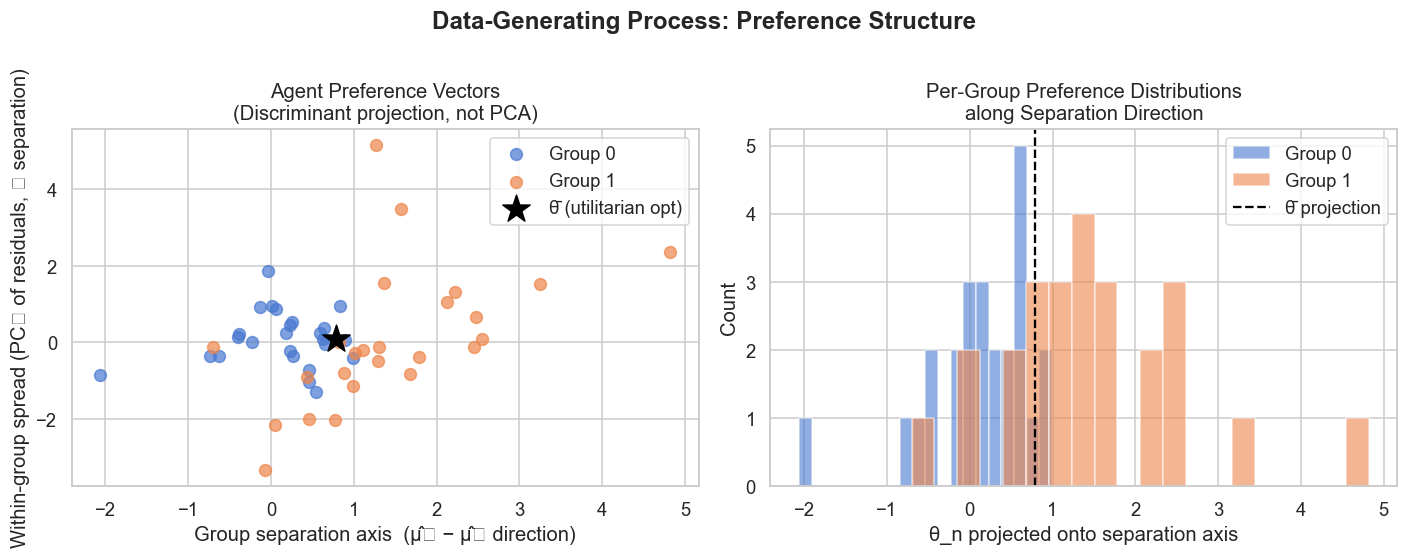


Group separation ||μ̂₁ - μ̂₀|| = 1.303
(Expected ~1.0 along dim 0, inflated by covariance noise)


In [121]:
# ── Project preferences onto group-discriminant axes ─────────────────────
# PCA finds max-variance directions, which need not align with group separation.
# Instead, use:
#   Axis 1 (horizontal): group mean difference direction  δ = μ̂_1 - μ̂_0  (LDA-style)
#   Axis 2 (vertical):   first PC of pooled within-group residuals (orthogonalized)

colors = sns.color_palette("muted", baseline_cfg.n_groups)

# Empirical group means
group_means_emp = np.array([dgp.theta[dgp.agent_groups == g].mean(0)
                             for g in range(baseline_cfg.n_groups)])

# Axis 1: separation direction
delta     = group_means_emp[1] - group_means_emp[0]      # (k,)
delta_hat = delta / np.linalg.norm(delta)                # unit vector

# Axis 2: first PC of within-group residuals, orthogonalized against delta_hat
residuals = np.vstack([
    dgp.theta[dgp.agent_groups == g] - group_means_emp[g]
    for g in range(baseline_cfg.n_groups)
])
pca_within = PCA(n_components=1)
pca_within.fit(residuals)
perp = pca_within.components_[0]
perp = perp - np.dot(perp, delta_hat) * delta_hat        # orthogonalize
perp = perp / np.linalg.norm(perp)

def project_2d(vecs):
    """Project (n, k) array onto [delta_hat, perp]."""
    return np.stack([vecs @ delta_hat, vecs @ perp], axis=1)

theta_2d = project_2d(dgp.theta)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: agent preference vectors in discriminant space
for g in range(baseline_cfg.n_groups):
    mask = dgp.agent_groups == g
    axes[0].scatter(theta_2d[mask, 0], theta_2d[mask, 1],
                    color=colors[g], label=f"Group {g}", alpha=0.7, s=60)

tb_2d = project_2d(dgp.theta_bar[None, :])[0]
axes[0].scatter(*tb_2d, marker='*', s=350, color='black', zorder=5, label='θ̄ (utilitarian opt)')
axes[0].set_xlabel("Group separation axis  (μ̂₁ − μ̂₀ direction)")
axes[0].set_ylabel("Within-group spread (PC₁ of residuals, ⊥ separation)")
axes[0].set_title("Agent Preference Vectors\n(Discriminant projection, not PCA)")
axes[0].legend()

# Right: histogram of each group's projection onto the separation axis
group_proj = dgp.theta @ delta_hat   # (N,)
for g in range(baseline_cfg.n_groups):
    mask = dgp.agent_groups == g
    axes[1].hist(group_proj[mask], bins=20, color=colors[g],
                 alpha=0.6, label=f"Group {g}", edgecolor='white')
axes[1].axvline(dgp.theta_bar @ delta_hat, color='black', linestyle='--',
                linewidth=1.5, label='θ̄ projection')
axes[1].set_xlabel("θ_n projected onto separation axis")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Group Preference Distributions\nalong Separation Direction")
axes[1].legend()

plt.suptitle("Data-Generating Process: Preference Structure", fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nGroup separation ||μ̂₁ - μ̂₀|| = {np.linalg.norm(delta):.3f}")
print(f"(Expected ~{baseline_cfg.mean_separation:.1f} along dim 0, inflated by covariance noise)")

---
## 2. Anonymous RLHF Fitting

**Anonymous RLHF** treats all $(n, z)$ observations as draws from a single representative agent —  
it pools labels without conditioning on who answered.

The estimator solves the **BTL / multinomial logit MLE**:

$$\hat{\theta}^{\text{RLHF}} = \arg\min_\theta\; \mathcal{L}_{\text{RLHF}}(\theta) = -\mathbb{E}_{(n,z) \sim q_\text{train}}\left[c \log \sigma(\alpha_z^\top \theta) + (1-c)\log(1-\sigma(\alpha_z^\top \theta))\right]$$

This is an **M-projection** of the pooled choice frequencies onto the single-parameter logistic family.  
Sklearn's `LogisticRegression` with no intercept and large `C` approximates this MLE.  

**Key distortion:** $\hat{\theta}^{\text{RLHF}} \neq \bar{\theta}$ in general — the pooled MLE does not recover the utilitarian preference.

In [122]:
class AnonymousRLHF:
    """
    Fits a single θ̂ by pooling all (agent, query) pairs.
    Uses sklearn LogisticRegression (no intercept, near-unregularized) to
    approximate the BTL MLE.
    """

    def __init__(self, C: float = 1e6):
        self.C = C
        self.theta_hat: Optional[np.ndarray] = None
        self.model: Optional[LogisticRegression] = None

    def fit(self, alpha: np.ndarray, labels: np.ndarray) -> np.ndarray:
        """
        alpha  : (n_obs, k)  query difference vectors
        labels : (n_obs,)    binary choices {0, 1}
        Returns theta_hat : (k,)
        """
        lr = LogisticRegression(
            fit_intercept=False, C=self.C,
            solver="lbfgs", max_iter=2000, tol=1e-8,
        )
        lr.fit(alpha, labels)
        self.theta_hat = lr.coef_.ravel()
        self.model = lr
        return self.theta_hat

    def predict_proba(self, alpha: np.ndarray) -> np.ndarray:
        """σ(α^T θ̂) for each query."""
        return sigmoid(alpha @ self.theta_hat)

||θ̂_RLHF - θ̄|| = 0.4428
||θ̂_RLHF||      = 0.4471
||θ̄||            = 0.8007

cosine(θ̂, θ̄)   = 0.9007


/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_27937/2999630694.py:30: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_27937/2999630694.py:30: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  plt.tight_layout()
/var/folders/yr/f3z1jw3j2390b9qngzcf_8mh0000gn/T/ipykernel_27937/2999630694.py:30: UserWarning: Glyph 8869 (\N{UP TACK}) missing from current font.
  plt.tight_layout()
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/michellesi/anaconda3/lib/python3.10/site-packages/IPython/core/pylab

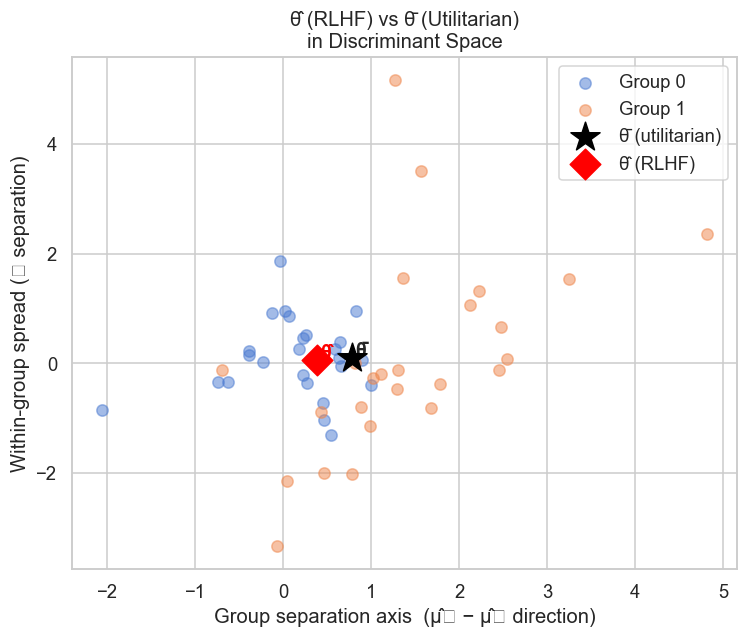

In [123]:
# ── Fit anonymous RLHF on baseline data ──────────────────────────────────
rlhf = AnonymousRLHF()
rlhf.fit(dgp.train_alpha, dgp.train_labels)

theta_dist = np.linalg.norm(rlhf.theta_hat - dgp.theta_bar)
print(f"||θ̂_RLHF - θ̄|| = {theta_dist:.4f}")
print(f"||θ̂_RLHF||      = {np.linalg.norm(rlhf.theta_hat):.4f}")
print(f"||θ̄||            = {np.linalg.norm(dgp.theta_bar):.4f}")
print(f"\ncosine(θ̂, θ̄)   = {np.dot(rlhf.theta_hat, dgp.theta_bar) / (np.linalg.norm(rlhf.theta_hat) * np.linalg.norm(dgp.theta_bar)):.4f}")

# ── Visualize θ̂ vs θ̄ in discriminant space ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
for g in range(baseline_cfg.n_groups):
    mask = dgp.agent_groups == g
    ax.scatter(theta_2d[mask, 0], theta_2d[mask, 1],
               color=colors[g], label=f"Group {g}", alpha=0.5, s=55)

th_2d = project_2d(rlhf.theta_hat[None, :])[0]
tb_2d = project_2d(dgp.theta_bar[None, :])[0]

ax.scatter(*tb_2d, marker='*', s=400, color='black', zorder=6, label='θ̄ (utilitarian)')
ax.scatter(*th_2d, marker='D', s=200, color='red',   zorder=6, label='θ̂ (RLHF)')
ax.annotate('θ̄', tb_2d + 0.03, fontsize=13, fontweight='bold')
ax.annotate('θ̂', th_2d + 0.03, fontsize=13, color='red', fontweight='bold')

ax.set_xlabel("Group separation axis  (μ̂₁ − μ̂₀ direction)")
ax.set_ylabel("Within-group spread (⊥ separation)")
ax.set_title("θ̂ (RLHF) vs θ̄ (Utilitarian)\nin Discriminant Space")
ax.legend()
plt.tight_layout()
plt.show()

---
## 3. Welfare Calculation

We compare three decision rules on the **deployment** query distribution $q_\text{dep}$:

| Rule | Formula | Description |
|------|---------|-------------|
| **Idealized (argmax)** | $W_n^*(z) = \max(\alpha_z^\top \theta_n,\, 0)$ | Agent makes own optimal choice |
| **Utilitarian optimal (softmax)** | $W_n(\bar{\theta}; z) = (\alpha_z^\top \theta_n)\, \sigma(\alpha_z^\top \bar{\theta})$ | Model with true social-planner prefs |
| **RLHF (softmax)** | $W_n(\hat{\theta}; z) = (\alpha_z^\top \theta_n)\, \sigma(\alpha_z^\top \hat{\theta})$ | Deployed anonymous RLHF model |

All three are averaged over deployment queries: $W_n = \mathbb{E}_{z \sim q_\text{dep}}[\cdots]$  (Eq. 6)

**Welfare decomposition:**
$$\underbrace{W_n^* - W_n(\hat{\theta})}_{\text{total loss}} = \underbrace{W_n^* - W_n(\bar{\theta})}_{\text{delegation loss}} + \underbrace{W_n(\bar{\theta}) - W_n(\hat{\theta})}_{\text{RLHF distortion}}$$

**Utilitarian social welfare:**  $W(\theta) = \sum_n w_n W_n(\theta)$

In [124]:
class WelfareCalculator:
    """
    Computes deployment welfare under three decision rules:
      (A) Idealized/argmax:   W_n^*(z) = max(α_z^T θ_n, 0)
      (B) Softmax/model:      W_n(θ; z) = (α_z^T θ_n) · σ(α_z^T θ)    [Eq. 6]

    Deployment welfare is the expectation over z ~ q_dep (approximated by sample mean).
    """

    def __init__(self, dgp: DataGeneratingProcess):
        self.dgp = dgp

    # ------------------------------------------------------------------
    def agent_welfare_softmax(self, theta: np.ndarray) -> np.ndarray:
        """
        W_n(theta) for every agent, averaged over deployment queries.  (Eq. 6)
        W_n(z; θ) = (α_z^T θ_n) · σ(α_z^T θ)
        Returns: (N,)
        """
        alpha  = self.dgp.alpha_deploy       # (Q_dep, k)
        thetas = self.dgp.theta              # (N, k)

        agent_logits = thetas @ alpha.T      # (N, Q_dep)  α_z^T θ_n
        model_probs  = sigmoid(alpha @ theta)  # (Q_dep,)  σ(α_z^T θ)

        welfare_nz = agent_logits * model_probs[None, :]  # (N, Q_dep)
        return welfare_nz.mean(axis=1)       # (N,)

    # ------------------------------------------------------------------
    def agent_welfare_argmax(self) -> np.ndarray:
        """
        Idealized welfare: agent always picks their preferred option.
        W_n^*(z) = max(α_z^T θ_n, 0)  — welfare gain above always picking y'.
        Returns: (N,)
        """
        alpha  = self.dgp.alpha_deploy       # (Q_dep, k)
        thetas = self.dgp.theta              # (N, k)
        agent_logits = thetas @ alpha.T      # (N, Q_dep)
        return np.maximum(agent_logits, 0).mean(axis=1)  # (N,)

    # ------------------------------------------------------------------
    def welfare_loss(self, theta: np.ndarray) -> np.ndarray:
        """Per-agent loss vs. idealized: W_n^* - W_n(theta). Returns: (N,)"""
        return self.agent_welfare_argmax() - self.agent_welfare_softmax(theta)

    def rlhf_distortion(self, theta_rlhf: np.ndarray,
                        theta_bar: Optional[np.ndarray] = None) -> np.ndarray:
        """Per-agent RLHF distortion: W_n(θ̄) - W_n(θ̂). Returns: (N,)"""
        if theta_bar is None:
            theta_bar = self.dgp.theta_bar
        return self.agent_welfare_softmax(theta_bar) - self.agent_welfare_softmax(theta_rlhf)

    def delegation_loss(self, theta_bar: Optional[np.ndarray] = None) -> np.ndarray:
        """Per-agent delegation loss: W_n^* - W_n(θ̄). Returns: (N,)"""
        if theta_bar is None:
            theta_bar = self.dgp.theta_bar
        return self.agent_welfare_argmax() - self.agent_welfare_softmax(theta_bar)

    # ------------------------------------------------------------------
    def social_welfare(self, theta: np.ndarray) -> float:
        """Utilitarian social welfare W(θ) = Σ_n w_n W_n(θ)."""
        return float(self.dgp.w @ self.agent_welfare_softmax(theta))

    def social_welfare_argmax(self) -> float:
        """Idealized social welfare Σ_n w_n W_n^*."""
        return float(self.dgp.w @ self.agent_welfare_argmax())

    # ------------------------------------------------------------------
    def summarize(self, theta_rlhf: np.ndarray,
                  theta_bar: Optional[np.ndarray] = None) -> pd.DataFrame:
        """Full per-agent welfare breakdown."""
        if theta_bar is None:
            theta_bar = self.dgp.theta_bar

        W_ideal = self.agent_welfare_argmax()
        W_opt   = self.agent_welfare_softmax(theta_bar)
        W_rlhf  = self.agent_welfare_softmax(theta_rlhf)

        return pd.DataFrame({
            "group":            self.dgp.agent_groups,
            "W_ideal":          W_ideal,
            "W_opt":            W_opt,
            "W_rlhf":           W_rlhf,
            "rlhf_distortion":  W_opt  - W_rlhf,
            "delegation_loss":  W_ideal - W_opt,
            "total_loss":       W_ideal - W_rlhf,
        })

In [125]:
# ── Compute welfare breakdown ─────────────────────────────────────────────
welfare = WelfareCalculator(dgp)
welfare_df = welfare.summarize(rlhf.theta_hat, dgp.theta_bar)

sw_ideal = welfare.social_welfare_argmax()
sw_opt   = welfare.social_welfare(dgp.theta_bar)
sw_rlhf  = welfare.social_welfare(rlhf.theta_hat)

print("=" * 55)
print("Social Welfare Summary")
print("=" * 55)
print(f"  W_ideal (argmax, individual):   {sw_ideal:.4f}")
print(f"  W_opt   (softmax, θ̄):           {sw_opt:.4f}")
print(f"  W_RLHF  (softmax, θ̂):           {sw_rlhf:.4f}")
print(f"  RLHF distortion (W_opt - W_RLHF): {sw_opt - sw_rlhf:.4f}")
print(f"  Delegation loss (W_ideal - W_opt): {sw_ideal - sw_opt:.4f}")
print()
print("Per-group averages:")
print(welfare_df.groupby("group")[
    ["W_ideal", "W_opt", "W_rlhf", "rlhf_distortion", "delegation_loss"]
].mean().round(4).to_string())

Social Welfare Summary
  W_ideal (argmax, individual):   1.0897
  W_opt   (softmax, θ̄):           0.1147
  W_RLHF  (softmax, θ̂):           0.0483
  RLHF distortion (W_opt - W_RLHF): 0.0664
  Delegation loss (W_ideal - W_opt): 0.9750

Per-group averages:
       W_ideal   W_opt  W_rlhf  rlhf_distortion  delegation_loss
group                                                           
0       0.8428  0.0133  0.0032           0.0101           0.8295
1       1.3366  0.2161  0.0934           0.1227           1.1205


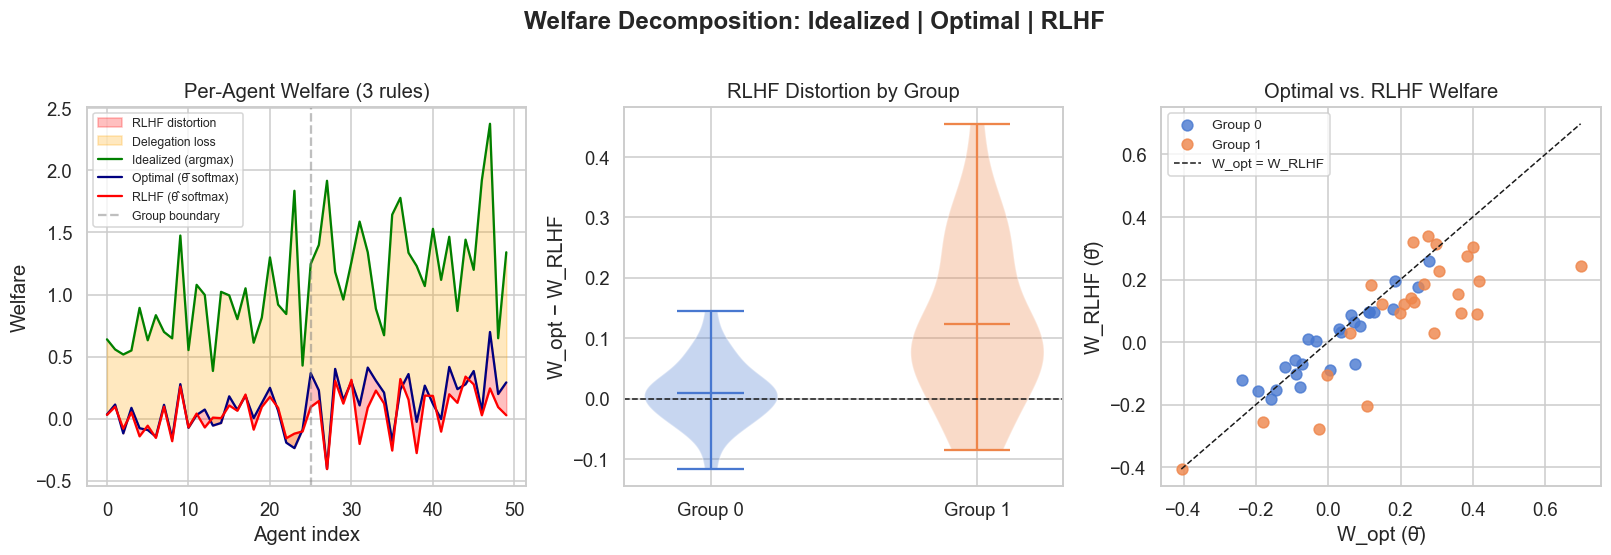

In [126]:
# ── Visualize per-agent welfare breakdown ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: per-agent welfare under three rules
ax = axes[0]
x = np.arange(baseline_cfg.n_agents)
ax.fill_between(x, welfare_df["W_rlhf"], welfare_df["W_opt"],
                alpha=0.25, color='red', label='RLHF distortion')
ax.fill_between(x, welfare_df["W_opt"], welfare_df["W_ideal"],
                alpha=0.25, color='orange', label='Delegation loss')
ax.plot(x, welfare_df["W_ideal"], label='Idealized (argmax)', color='green', linewidth=1.5)
ax.plot(x, welfare_df["W_opt"],   label='Optimal (θ̄ softmax)', color='navy',  linewidth=1.5)
ax.plot(x, welfare_df["W_rlhf"],  label='RLHF (θ̂ softmax)',  color='red',   linewidth=1.5)
ax.axvline(baseline_cfg.n_agents // 2, color='gray', linestyle='--', alpha=0.5, label='Group boundary')
ax.set_xlabel("Agent index"); ax.set_ylabel("Welfare")
ax.set_title("Per-Agent Welfare (3 rules)")
ax.legend(fontsize=8)

# Panel B: RLHF distortion per group
ax = axes[1]
for g in range(baseline_cfg.n_groups):
    gdf = welfare_df[welfare_df["group"] == g]
    ax.violinplot(gdf["rlhf_distortion"], positions=[g],
                  showmeans=True, showextrema=True)
ax.axhline(0, color='k', linestyle='--', linewidth=1)
ax.set_xticks(range(baseline_cfg.n_groups))
ax.set_xticklabels([f"Group {g}" for g in range(baseline_cfg.n_groups)])
ax.set_ylabel("W_opt − W_RLHF")
ax.set_title("RLHF Distortion by Group")

# Panel C: scatter W_opt vs W_rlhf, colored by group
ax = axes[2]
for g in range(baseline_cfg.n_groups):
    mask = welfare_df["group"] == g
    ax.scatter(welfare_df.loc[mask, "W_opt"], welfare_df.loc[mask, "W_rlhf"],
               color=colors[g], label=f"Group {g}", alpha=0.8, s=50)
lims = [min(welfare_df["W_opt"].min(), welfare_df["W_rlhf"].min()),
        max(welfare_df["W_opt"].max(), welfare_df["W_rlhf"].max())]
ax.plot(lims, lims, 'k--', linewidth=1, label='W_opt = W_RLHF')
ax.set_xlabel("W_opt (θ̄)"); ax.set_ylabel("W_RLHF (θ̂)")
ax.set_title("Optimal vs. RLHF Welfare")
ax.legend(fontsize=9)

plt.suptitle("Welfare Decomposition: Idealized | Optimal | RLHF", fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 4. Alignment Externalities

The **alignment externality** $\Gamma^m_{n,z}$ measures the marginal effect on agent $m$'s welfare  
from infinitesimally upweighting agent $n$'s response to query $z$ in training.

**General influence-function formula (Lemma 2 / Eq. 12):**
$$\Gamma^m_{n,z} = \nabla_\theta W_m(\hat{\theta})^\top \, J(\hat{\theta})^{-1} \, s_{n,z}(\hat{\theta})$$

where:
- $J = \mathbb{E}_{(n,z)}[v(\alpha_z^\top \hat{\theta})\, \alpha_z \alpha_z^\top]$ — Fisher information (population Hessian)
- $s_{n,z} = (\sigma(\alpha_z^\top \theta_n) - \sigma(\alpha_z^\top \hat{\theta}))\, \alpha_z$ — expected score contribution (Eq. 14)
- $\nabla_\theta W_n = \mathbb{E}_z[(\alpha_z^\top \theta_n)\, v(\alpha_z^\top \hat{\theta})\, \alpha_z]$ — welfare gradient (Eq. 14)

**Closed-form for social welfare externality (Eq. 16):**
$$\Gamma^{\text{social}}_{n,z} = (\sigma(\alpha_z^\top \theta_n) - \sigma(\alpha_z^\top \hat{\theta}))\; \alpha_z^\top \eta$$

where $\eta = J^{-1} \nabla_\theta W(\hat{\theta})$ is the **natural gradient of social welfare**.

**Proposition 1:** $\mathbb{E}_{(n,z) \sim q_\text{train}}[\Gamma^{\text{social}}_{n,z}] = 0$  
→ Under- and over-representation must average out across the training mixture.

In [127]:
class AlignmentExternality:
    """
    Computes alignment externalities via two methods:

    Method A – General Influence Function (IF)  [Lemma 2, Eq. 12]
        Γ^m_{n,z} = ∇_θ W_m(θ̂)^T J^{-1} s_{n,z}(θ̂)   — per-agent externality

        s_{n,z} uses the EXPECTED score (σ(α^T θ_n) − σ(α^T θ̂))·α rather than the
        observed label residual (y − σ(α^T θ̂))·α. These are equal in expectation
        (E[y] = σ_true), matching the paper's Eq. 14 / closed-form Eq. 16.
        This measures the *inclusion benefit* of observation (n,z): positive = including
        this observation increases social welfare.

    Method B – Closed-form Social Welfare Externality  [Eq. 16]
        Γ^social_{n,z} = (σ(α_z^T θ_n) - σ(α_z^T θ̂)) · α_z^T η
        where η = J^{-1} ∇_θ W(θ̂)  — natural gradient of social welfare

    Method C – Leave-One-Out (LOO)  [ground truth]
        Re-fit RLHF without obs (n,z), return W(θ̂) − W(θ̂_{-i}).
        This is the *cost of removal* = benefit of inclusion, matching the sign of IF.
        (Note: returns W_full − W_loo, not W_loo − W_full.)
    """

    def __init__(self, dgp: DataGeneratingProcess, rlhf: AnonymousRLHF,
                 welfare_calc: WelfareCalculator):
        self.dgp     = dgp
        self.rlhf    = rlhf
        self.welfare = welfare_calc
        self._precompute()

    def _precompute(self):
        """Precompute J, J^{-1}, welfare gradients ∇W_n, and η."""
        theta = self.rlhf.theta_hat         # (k,)
        alpha = self.dgp.train_alpha        # (n_obs, k)
        n_obs = alpha.shape[0]

        # Fisher information J = (1/n) Σ_i v_i α_i α_i^T
        p_hat = sigmoid(alpha @ theta)                          # (n_obs,)
        v_hat = p_hat * (1 - p_hat)                             # σ(1-σ)
        self.J     = (alpha * v_hat[:, None]).T @ alpha / n_obs  # (k, k)
        self.J_inv = inv(self.J + 1e-8 * np.eye(self.J.shape[0]))

        # Deployment quantities
        alpha_dep = self.dgp.alpha_deploy                       # (Q_dep, k)
        p_dep     = sigmoid(alpha_dep @ theta)                  # (Q_dep,)
        v_dep     = p_dep * (1 - p_dep)                         # (Q_dep,)
        thetas    = self.dgp.theta                              # (N, k)

        # ── Per-agent welfare gradients ∇_θ W_n  (Eq. 14) ──────────
        # ∇_θ W_n = E_z[(α_z^T θ_n) · v(α_z^T θ̂) · α_z]
        agent_logits_dep = thetas @ alpha_dep.T                 # (N, Q_dep)
        self.welfare_grads = (
            (agent_logits_dep[:, :, None] * v_dep[None, :, None]) * alpha_dep[None, :, :]
        ).mean(axis=1)                                          # (N, k)

        # ── Natural gradient of social welfare η = J^{-1} ∇_θ W  ───
        sw_grad = ((alpha_dep @ self.dgp.theta_bar) * v_dep)[:, None] * alpha_dep
        sw_grad = sw_grad.mean(axis=0)                          # (k,)
        self.eta = self.J_inv @ sw_grad                         # (k,)

    # ── Score function (expected, per paper's Eq. 14) ─────────────────────
    def score(self, obs_idx: int) -> np.ndarray:
        """
        Expected score s_{n,z}(θ̂) = (σ(α_z^T θ_n) − σ(α_z^T θ̂)) · α_z.
        Uses the true agent probability, not the observed label — equals the
        standard MLE score in expectation. (Paper Eq. 14)
        """
        theta   = self.rlhf.theta_hat
        alpha_z = self.dgp.train_alpha[obs_idx]         # (k,)
        n       = self.dgp.train_agent_idx[obs_idx]
        theta_n = self.dgp.theta[n]
        return (sigmoid(alpha_z @ theta_n) - sigmoid(alpha_z @ theta)) * alpha_z

    # ── Method A: General IF — per-agent externality ─────────────────────
    def influence_externality(self, obs_idx: int) -> np.ndarray:
        """
        Γ^m_{n,z} for all m simultaneously.  (Lemma 2 / Eq. 12)
        Positive = including this observation increases agent m's welfare.
        Returns: (N,)
        """
        s       = self.score(obs_idx)           # (k,)
        J_inv_s = self.J_inv @ s                # (k,)
        return self.welfare_grads @ J_inv_s     # (N,)

    def aggregate_if_externalities(self) -> np.ndarray:
        """E_{n,z}[Γ^m_{n,z}] — should ≈ 0 per Prop. 1. Returns: (N,)"""
        n_obs  = self.dgp.train_alpha.shape[0]
        gammas = np.stack([self.influence_externality(i) for i in range(n_obs)])
        return gammas.mean(axis=0)

    # ── Method B: Closed-form social welfare externality (Eq. 16) ────────
    def social_externality_closed_form(self, obs_idx: int) -> float:
        """
        Γ^social_{n,z} = (σ(α_z^T θ_n) − σ(α_z^T θ̂)) · α_z^T η  (Eq. 16)
        """
        theta   = self.rlhf.theta_hat
        alpha_z = self.dgp.train_alpha[obs_idx]
        n       = self.dgp.train_agent_idx[obs_idx]
        theta_n = self.dgp.theta[n]
        score_scalar = sigmoid(alpha_z @ theta_n) - sigmoid(alpha_z @ theta)
        return float(score_scalar * (alpha_z @ self.eta))

    def social_externality_from_if(self, obs_idx: int) -> float:
        """Social welfare externality via general IF: Σ_m w_m Γ^m_{n,z}."""
        return float(self.dgp.w @ self.influence_externality(obs_idx))

    # ── Method C: Leave-One-Out (LOO) ─────────────────────────────────────
    def loo_social_welfare_change(self, obs_idx: int, C: float = 1e6) -> float:
        """
        Re-fit RLHF without observation obs_idx.
        Returns W(θ̂) − W(θ̂_{-i}): the *cost of removal* = benefit of inclusion.
        Sign matches IF externality (positive = this observation helps social welfare).
        """
        mask = np.ones(self.dgp.train_alpha.shape[0], dtype=bool)
        mask[obs_idx] = False

        rlhf_loo = AnonymousRLHF(C=C)
        rlhf_loo.fit(self.dgp.train_alpha[mask], self.dgp.train_labels[mask])

        W_full = self.welfare.social_welfare(self.rlhf.theta_hat)
        W_loo  = self.welfare.social_welfare(rlhf_loo.theta_hat)
        return W_full - W_loo   # cost of removal (was W_loo - W_full — wrong sign)

    # ── IF vs LOO comparison ───────────────────────────────────────────────
    def compare_if_vs_loo(self, n_samples: int = 50, seed: int = 0) -> pd.DataFrame:
        """
        Compare IF estimate vs LOO for a random subset of training observations.
        Both measure the *benefit of inclusion*: positive = this observation helps.
        Columns: obs_idx, agent, group, if_social, closed_form_social, loo_social
        """
        rng   = np.random.default_rng(seed)
        n_obs = self.dgp.train_alpha.shape[0]
        idxs  = rng.choice(n_obs, size=min(n_samples, n_obs), replace=False)

        records = []
        for i in idxs:
            sw_if  = self.social_externality_from_if(i)
            sw_cf  = self.social_externality_closed_form(i)
            sw_loo = self.loo_social_welfare_change(i)
            n_agent = self.dgp.train_agent_idx[i]
            records.append({
                "obs_idx":            i,
                "agent":              n_agent,
                "group":              self.dgp.agent_groups[n_agent],
                "if_social":          sw_if,
                "closed_form_social": sw_cf,
                "loo_social":         sw_loo,
            })

        return pd.DataFrame(records)

In [128]:
# ── Fit externality calculator on baseline ────────────────────────────────
ext = AlignmentExternality(dgp, rlhf, welfare)

# Verify Proposition 1: average externality ≈ 0
avg_ext = ext.aggregate_if_externalities()  # (N,)
sw_avg_ext = float(dgp.w @ avg_ext)

print("Proposition 1 check (average externality should ≈ 0):")
print(f"  Mean per-agent externality: {avg_ext.mean():.6f}")
print(f"  Max |per-agent|:            {np.abs(avg_ext).max():.6f}")
print(f"  Social welfare avg ext:     {sw_avg_ext:.8f}")

# Closed-form vs general IF on a few samples
print("\nClosed-form (Eq.16) vs general IF [should match exactly]:")
for i in np.random.default_rng(0).choice(100, size=5, replace=False):
    cf  = ext.social_externality_closed_form(i)
    gen = ext.social_externality_from_if(i)
    print(f"  obs {i:3d}: closed-form = {cf:+.6f}   general IF = {gen:+.6f}  diff = {abs(cf-gen):.2e}")

Proposition 1 check (average externality should ≈ 0):
  Mean per-agent externality: -0.007763
  Max |per-agent|:            0.080661
  Social welfare avg ext:     -0.00776315

Closed-form (Eq.16) vs general IF [should match exactly]:
  obs  61: closed-form = -0.213799   general IF = -0.213799  diff = 1.67e-16
  obs  50: closed-form = +0.409145   general IF = +0.409145  diff = 1.11e-16
  obs  26: closed-form = -0.095895   general IF = -0.095895  diff = 1.39e-17
  obs  30: closed-form = +0.166436   general IF = +0.166436  diff = 2.78e-17
  obs  81: closed-form = +0.096226   general IF = +0.096226  diff = 2.78e-16


---
## 5. Influence Function vs. Leave-One-Out Validation

We validate the IF approximation by comparing it to the ground-truth LOO change in social welfare.

Good agreement (high correlation, low MAE) means the IF is a reliable cheap proxy for the expensive LOO.

In [129]:
# ── Run IF vs LOO comparison (small DGP for speed) ───────────────────────
loo_cfg = DGPConfig(
    n_agents=30, k_dim=6, n_train_queries=300, n_deploy_queries=100,
    n_groups=2, mean_separation=1.0, cov_delta=0.4, seed=7,
)
loo_dgp     = DataGeneratingProcess(loo_cfg)
loo_rlhf    = AnonymousRLHF()
loo_rlhf.fit(loo_dgp.train_alpha, loo_dgp.train_labels)
loo_welfare = WelfareCalculator(loo_dgp)
loo_ext     = AlignmentExternality(loo_dgp, loo_rlhf, loo_welfare)

loo_df = loo_ext.compare_if_vs_loo(n_samples=80, seed=7)

corr_if_loo = loo_df[["if_social", "loo_social"]].corr().iloc[0, 1]
corr_cf_loo = loo_df[["closed_form_social", "loo_social"]].corr().iloc[0, 1]
mae_if      = (loo_df["if_social"] - loo_df["loo_social"]).abs().mean()
mae_cf      = (loo_df["closed_form_social"] - loo_df["loo_social"]).abs().mean()

print(f"IF  vs LOO — Correlation: {corr_if_loo:.4f}   MAE: {mae_if:.6f}")
print(f"CF  vs LOO — Correlation: {corr_cf_loo:.4f}   MAE: {mae_cf:.6f}")
print("\nSample rows:")
print(loo_df.head(8).round(6).to_string(index=False))

IF  vs LOO — Correlation: 0.3777   MAE: 0.198819
CF  vs LOO — Correlation: 0.3777   MAE: 0.198819

Sample rows:
 obs_idx  agent  group  if_social  closed_form_social  loo_social
     121     16      1  -0.131436           -0.131436   -0.001122
     280      3      0  -0.001048           -0.001048    0.001587
     244      4      0  -0.167338           -0.167338   -0.001122
     174      9      0  -0.215178           -0.215178   -0.002132
      42      1      0   0.241229            0.241229    0.001456
     228     18      1   0.244725            0.244725    0.000961
       9      8      0  -0.178732           -0.178732    0.001294
     274      7      0   0.085502            0.085502    0.000410


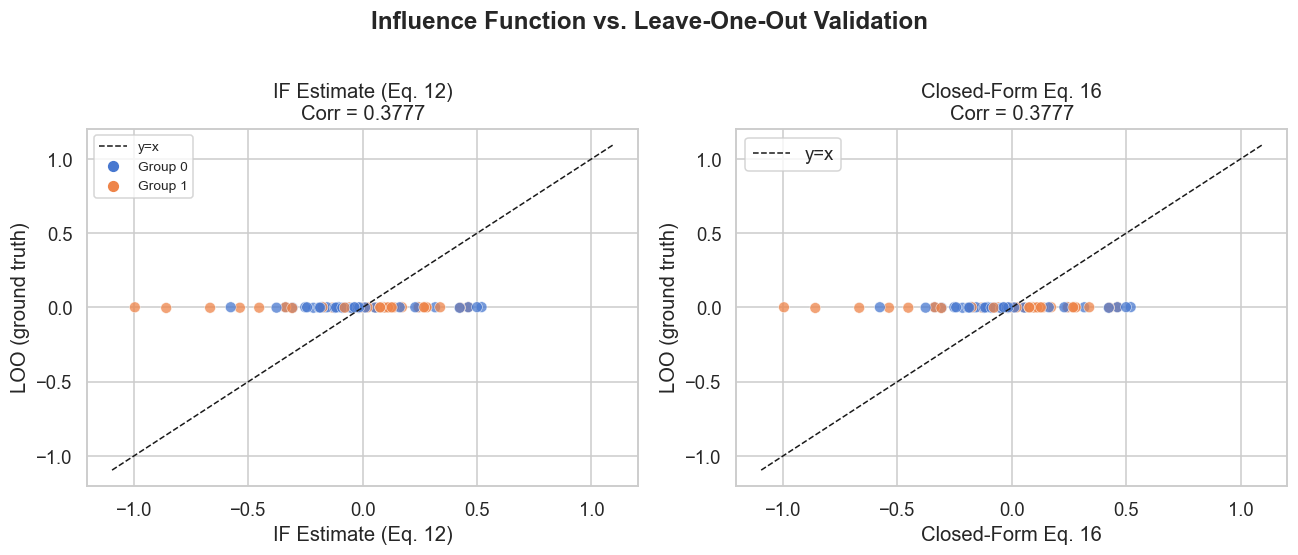

In [130]:
# ── Plot IF vs LOO ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

loo_colors = [colors[g] for g in loo_df["group"]]

for ax, (xcol, xlabel) in zip(axes, [
    ("if_social",          "IF Estimate (Eq. 12)"),
    ("closed_form_social", "Closed-Form Eq. 16"),
]):
    ax.scatter(loo_df[xcol], loo_df["loo_social"],
               c=loo_colors, alpha=0.75, s=50, edgecolors='white', linewidths=0.4)
    lim = max(loo_df[[xcol, "loo_social"]].abs().max().max() * 1.1, 1e-6)
    ax.plot([-lim, lim], [-lim, lim], 'k--', linewidth=1, label='y=x')
    ax.set_xlabel(xlabel); ax.set_ylabel("LOO (ground truth)")
    corr_val = loo_df[[xcol, "loo_social"]].corr().iloc[0, 1]
    ax.set_title(f"{xlabel}\nCorr = {corr_val:.4f}")
    ax.legend()

# Group legend
for g in range(loo_cfg.n_groups):
    axes[0].scatter([], [], color=colors[g], label=f"Group {g}", s=40)
axes[0].legend(fontsize=9)

plt.suptitle("Influence Function vs. Leave-One-Out Validation", fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## 6. Full Experiment + Sweep Simulations

We sweep over four experimental axes to understand when RLHF distortion is largest:

1. **Mean separation** — how far apart are the group preference means?
2. **Number of agents N** — does distortion shrink as the annotator pool grows?
3. **Feature dimensionality k** — more dimensions → more misalignment directions?
4. **Minority welfare weight** — whose preferences get overridden most?


In [131]:
class Experiment:
    """Wires DGP → RLHF → Welfare → Externalities into one run."""

    def __init__(self, cfg: DGPConfig):
        self.cfg     = cfg
        self.dgp     = DataGeneratingProcess(cfg)
        self.rlhf    = AnonymousRLHF()
        self.welfare = WelfareCalculator(self.dgp)
        self.ext: Optional[AlignmentExternality] = None

    def run(self) -> dict:
        dgp  = self.dgp
        rlhf = self.rlhf

        rlhf.fit(dgp.train_alpha, dgp.train_labels)

        welfare_df = self.welfare.summarize(rlhf.theta_hat, dgp.theta_bar)

        sw_ideal = self.welfare.social_welfare_argmax()
        sw_opt   = self.welfare.social_welfare(dgp.theta_bar)
        sw_rlhf  = self.welfare.social_welfare(rlhf.theta_hat)

        self.ext = AlignmentExternality(dgp, rlhf, self.welfare)
        avg_ext  = self.ext.aggregate_if_externalities()

        return {
            "cfg":           self.cfg,
            "theta_hat":     rlhf.theta_hat,
            "theta_bar":     dgp.theta_bar,
            "theta_dist":    float(np.linalg.norm(rlhf.theta_hat - dgp.theta_bar)),
            "sw_ideal":      sw_ideal,
            "sw_opt":        sw_opt,
            "sw_rlhf":       sw_rlhf,
            "sw_gap":        sw_opt - sw_rlhf,          # RLHF distortion
            "sw_deleg_loss": sw_ideal - sw_opt,         # delegation loss
            "welfare_df":    welfare_df,
            "avg_externality": avg_ext,
        }


# ── Sweep helpers ──────────────────────────────────────────────────────────

def run_baseline() -> dict:
    cfg = DGPConfig(n_agents=50, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
                    n_groups=2, mean_separation=1.0, cov_delta=0.5, seed=42)
    return Experiment(cfg).run()


def sweep_mean_separation(separations=None) -> pd.DataFrame:
    """Welfare distortion as group preference means diverge."""
    separations = separations or [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
    records = []
    for sep in separations:
        cfg = DGPConfig(n_agents=50, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
                        n_groups=2, mean_separation=sep, cov_delta=0.3, seed=0)
        res = Experiment(cfg).run()
        records.append({"mean_separation": sep, "sw_gap": res["sw_gap"],
                        "theta_dist": res["theta_dist"]})
    return pd.DataFrame(records)


def sweep_n_agents(agent_counts=None) -> pd.DataFrame:
    """Does distortion shrink as N → ∞?"""
    agent_counts = agent_counts or [5, 10, 25, 50, 100, 200]
    records = []
    for N in agent_counts:
        cfg = DGPConfig(n_agents=N, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
                        n_groups=2, mean_separation=1.0, cov_delta=0.5, seed=0)
        res = Experiment(cfg).run()
        records.append({"n_agents": N, "sw_gap": res["sw_gap"],
                        "theta_dist": res["theta_dist"]})
    return pd.DataFrame(records)


def sweep_k_dim(dims=None) -> pd.DataFrame:
    """Effect of feature dimensionality on distortion."""
    dims = dims or [2, 4, 8, 16, 32]
    records = []
    for k in dims:
        cfg = DGPConfig(n_agents=50, k_dim=k, n_train_queries=1000, n_deploy_queries=200,
                        n_groups=2, mean_separation=1.0, cov_delta=0.5, seed=0)
        res = Experiment(cfg).run()
        records.append({"k_dim": k, "sw_gap": res["sw_gap"],
                        "theta_dist": res["theta_dist"]})
    return pd.DataFrame(records)


def sweep_group_weights() -> pd.DataFrame:
    """Which groups are hurt most under different social welfare weights?"""
    records = []
    N = 50
    for minority_w in [0.1, 0.3, 0.5, 0.7, 0.9]:
        n_min = N // 5  # 20% of agents
        n_maj = N - n_min
        w = np.concatenate([
            np.full(n_maj, (1 - minority_w) / n_maj),
            np.full(n_min, minority_w / n_min),
        ])
        cfg = DGPConfig(n_agents=N, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
                        n_groups=2, mean_separation=1.5, cov_delta=0.5, seed=0,
                        group_weights=w)
        res = Experiment(cfg).run()
        wdf = res["welfare_df"]
        records.append({
            "minority_weight":    minority_w,
            "sw_gap":             res["sw_gap"],
            "distortion_majority": wdf[wdf.group == 0]["rlhf_distortion"].mean(),
            "distortion_minority": wdf[wdf.group == 1]["rlhf_distortion"].mean(),
        })
    return pd.DataFrame(records)

In [132]:
# ── Run all sweeps ────────────────────────────────────────────────────────
print("Running sweep experiments... (may take ~60s)")
res_baseline = run_baseline()
df_sep  = sweep_mean_separation()
df_n    = sweep_n_agents()
df_k    = sweep_k_dim()
df_gw   = sweep_group_weights()

print("\n[Baseline]")
print(f"  SW gap (distortion): {res_baseline['sw_gap']:.4f}")
print(f"  ||θ̂ - θ̄||:          {res_baseline['theta_dist']:.4f}")
print(f"  Avg externality:     {res_baseline['avg_externality'].mean():.6f}")

print("\n[Mean Separation Sweep]")
print(df_sep.to_string(index=False))
print("\n[N Agents Sweep]")
print(df_n.to_string(index=False))
print("\n[k_dim Sweep]")
print(df_k.to_string(index=False))
print("\n[Group Weight Sweep]")
print(df_gw.to_string(index=False))

Running sweep experiments... (may take ~60s)

[Baseline]
  SW gap (distortion): 0.0664
  ||θ̂ - θ̄||:          0.4428
  Avg externality:     -0.007763

[Mean Separation Sweep]
 mean_separation   sw_gap  theta_dist
             0.0 0.007267    0.264409
             0.5 0.022187    0.327796
             1.0 0.048357    0.419889
             1.5 0.088361    0.561469
             2.0 0.141492    0.741211
             3.0 0.230992    1.070943

[N Agents Sweep]
 n_agents   sw_gap  theta_dist
        5 0.095668    0.552839
       10 0.068774    0.514755
       25 0.055549    0.443349
       50 0.051353    0.435672
      100 0.046484    0.405470
      200 0.024559    0.327881

[k_dim Sweep]
 k_dim   sw_gap  theta_dist
     2 0.018488    0.226611
     4 0.029805    0.234162
     8 0.051353    0.435672
    16 0.041633    0.449501
    32 0.162807    0.878521

[Group Weight Sweep]
 minority_weight   sw_gap  distortion_majority  distortion_minority
             0.1 0.071758             0.027885    

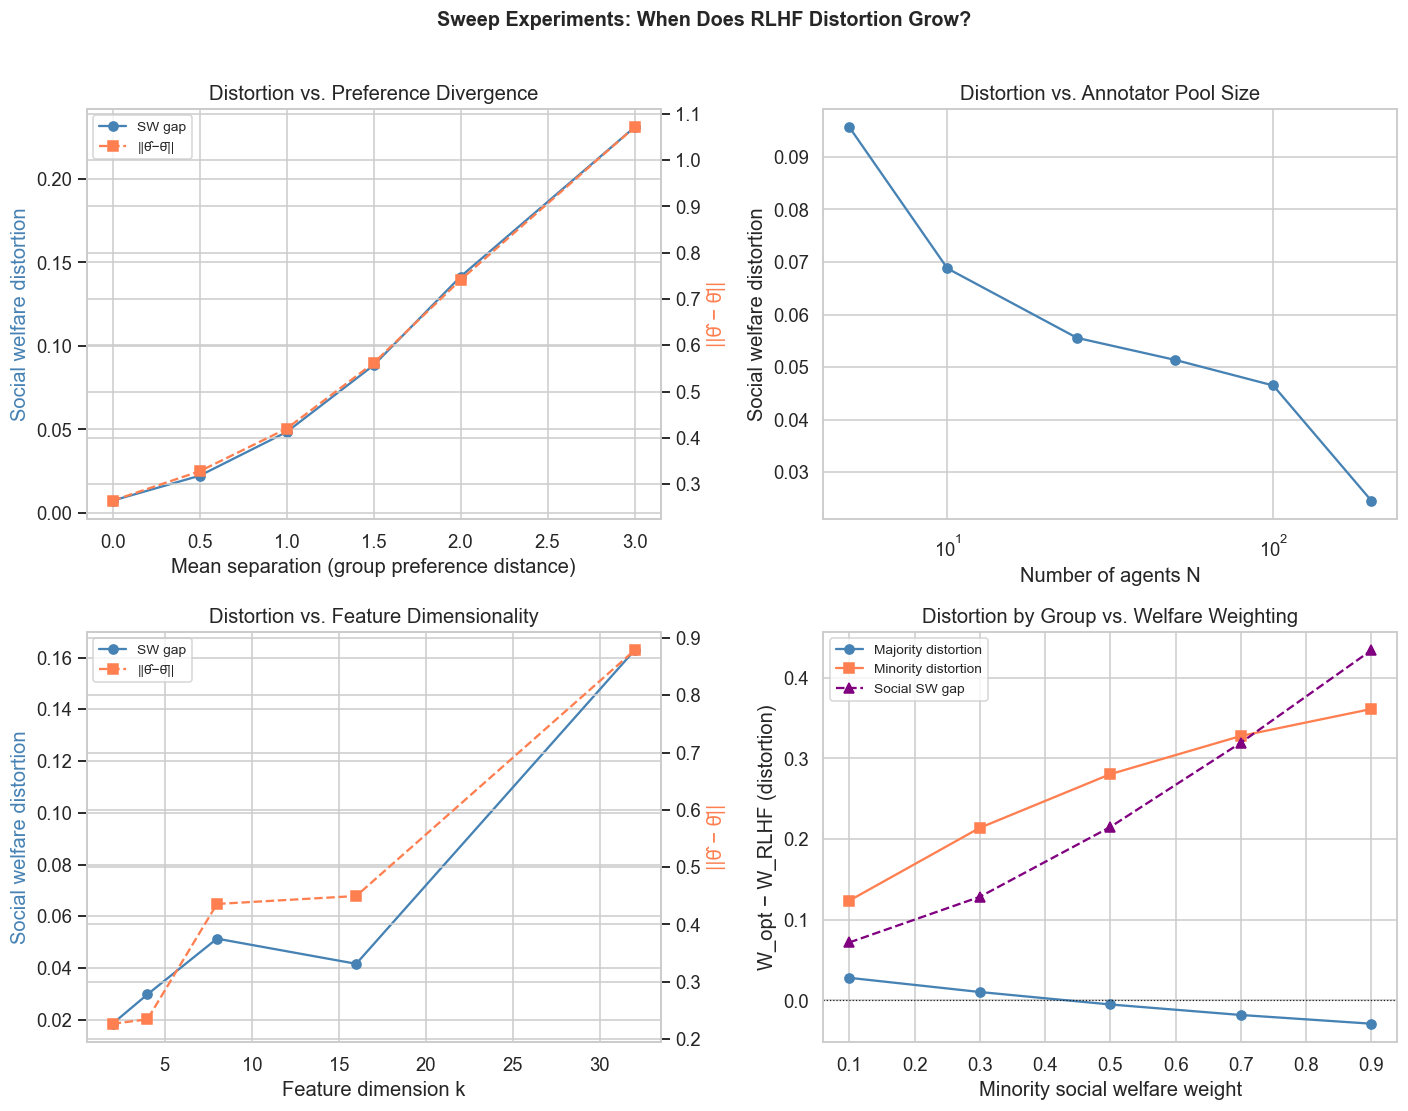

In [133]:
# ── Plot sweep results ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Mean separation
ax = axes[0, 0]
ax2 = ax.twinx()
ax.plot(df_sep["mean_separation"], df_sep["sw_gap"],  'o-', color='steelblue', label='SW gap')
ax2.plot(df_sep["mean_separation"], df_sep["theta_dist"], 's--', color='coral', label='||θ̂−θ̄||')
ax.set_xlabel("Mean separation (group preference distance)")
ax.set_ylabel("Social welfare distortion", color='steelblue')
ax2.set_ylabel("||θ̂ − θ̄||", color='coral')
ax.set_title("Distortion vs. Preference Divergence")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# 2. N agents
ax = axes[0, 1]
ax.plot(df_n["n_agents"], df_n["sw_gap"], 'o-', color='steelblue')
ax.set_xlabel("Number of agents N")
ax.set_ylabel("Social welfare distortion")
ax.set_title("Distortion vs. Annotator Pool Size")
ax.set_xscale("log")

# 3. k dimensionality
ax = axes[1, 0]
ax2 = ax.twinx()
ax.plot(df_k["k_dim"], df_k["sw_gap"],  'o-', color='steelblue', label='SW gap')
ax2.plot(df_k["k_dim"], df_k["theta_dist"], 's--', color='coral', label='||θ̂−θ̄||')
ax.set_xlabel("Feature dimension k")
ax.set_ylabel("Social welfare distortion", color='steelblue')
ax2.set_ylabel("||θ̂ − θ̄||", color='coral')
ax.set_title("Distortion vs. Feature Dimensionality")
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9)

# 4. Group weights
ax = axes[1, 1]
ax.plot(df_gw["minority_weight"], df_gw["distortion_majority"],
        'o-', color='steelblue', label='Majority distortion')
ax.plot(df_gw["minority_weight"], df_gw["distortion_minority"],
        's-', color='coral', label='Minority distortion')
ax.plot(df_gw["minority_weight"], df_gw["sw_gap"],
        '^--', color='purple', label='Social SW gap')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.set_xlabel("Minority social welfare weight")
ax.set_ylabel("W_opt − W_RLHF (distortion)")
ax.set_title("Distortion by Group vs. Welfare Weighting")
ax.legend(fontsize=9)

plt.suptitle("Sweep Experiments: When Does RLHF Distortion Grow?",
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 8. Who Bears the Distortion? Four Levers

The magnitude of RLHF distortion depends on *structural* features of the training and deployment setup.
We sweep over four levers and track **per-group distortion** (W_opt − W_RLHF) separately for each group,
making it explicit which group is hurt under which conditions.

| Lever | What it changes | Mechanism |
|-------|----------------|-----------|
| **Annotation bias** | Fraction of training labels from each group | θ̂ is pulled toward the over-represented group's preferences |
| **Annotator pool composition** | Number of agents per group | With uniform per-agent sampling, larger groups contribute proportionally more labels |
| **Training query bias** | Direction of training queries | Queries biased toward one group's preferred region affect Fisher info and score direction |
| **Deployment query bias** | Direction of deployment queries | Mismatch between where preferences are *tested* vs. where the model *operates* |

**Reading the plots:** When a group's line is above zero, that group is bearing a positive distortion cost
(the model underserves them relative to the utilitarian optimum). Crossing zero means the model happens
to serve them *better* than θ̄ would — which can happen when deployment queries are biased toward them.

> `mean_separation=1.5` is used here (vs 1.0 in earlier sweeps) to make distortion effects more visible.

In [134]:
def _per_group_distortion(res: dict, n_groups: int) -> dict:
    """Extract mean per-group distortion and social welfare gap from an Experiment result."""
    wdf = res["welfare_df"]
    return {
        **{f"distortion_g{g}": wdf[wdf.group == g]["rlhf_distortion"].mean()
           for g in range(n_groups)},
        "sw_gap": res["sw_gap"],
    }


def _base_cfg(**overrides):
    """Shared baseline config for the 4-lever sweeps."""
    return dict(n_agents=50, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
                n_groups=2, mean_separation=1.5, cov_delta=0.5, seed=0)


def _query_mean(bias: float, k: int) -> Optional[np.ndarray]:
    """Convenience: scalar bias along dim 0 → k-dim mean vector."""
    if bias == 0.0:
        return None
    v = np.zeros(k)
    v[0] = bias
    return v


# ── Lever 1: Training annotation bias ─────────────────────────────────────
def sweep_annotation_bias(group0_fracs=None) -> pd.DataFrame:
    group0_fracs = group0_fracs or [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]
    records = []
    for f0 in group0_fracs:
        cfg = DGPConfig(**_base_cfg(), train_group_fracs=[f0, 1 - f0])
        res = Experiment(cfg).run()
        records.append({"group0_train_frac": f0, **_per_group_distortion(res, 2)})
    return pd.DataFrame(records)


# ── Lever 2: Annotator pool composition ───────────────────────────────────
def sweep_pool_composition(group0_fracs=None) -> pd.DataFrame:
    group0_fracs = group0_fracs or [0.1, 0.2, 0.3, 0.5, 0.7, 0.8, 0.9]
    N = 50
    records = []
    for f0 in group0_fracs:
        n0 = max(1, round(N * f0))
        cfg = DGPConfig(**_base_cfg(), group_sizes=[n0, N - n0])
        res = Experiment(cfg).run()
        records.append({"group0_pool_frac": f0, **_per_group_distortion(res, 2)})
    return pd.DataFrame(records)


# ── Lever 3: Training query mean ───────────────────────────────────────────
def sweep_train_query_bias(biases=None) -> pd.DataFrame:
    """
    Vary the mean of the training query distribution along the group-separation axis (dim 0).
    bias > 0 → queries concentrated toward group 1's preferred direction.
    bias < 0 → queries concentrated toward group 0's preferred direction.
    """
    biases = biases or [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
    k = 8
    records = []
    for b in biases:
        cfg = DGPConfig(**_base_cfg(), train_query_mean=_query_mean(b, k))
        res = Experiment(cfg).run()
        records.append({"train_query_bias": b, **_per_group_distortion(res, 2)})
    return pd.DataFrame(records)


# ── Lever 4: Deployment query mean ────────────────────────────────────────
def sweep_deploy_query_bias(biases=None) -> pd.DataFrame:
    """
    Vary the mean of the deployment query distribution along the group-separation axis (dim 0).
    """
    biases = biases or [-2.0, -1.0, -0.5, 0.0, 0.5, 1.0, 2.0]
    k = 8
    records = []
    for b in biases:
        cfg = DGPConfig(**_base_cfg(), deploy_query_mean=_query_mean(b, k))
        res = Experiment(cfg).run()
        records.append({"deploy_query_bias": b, **_per_group_distortion(res, 2)})
    return pd.DataFrame(records)

Running 4-lever sweeps... (~90s)
Done.


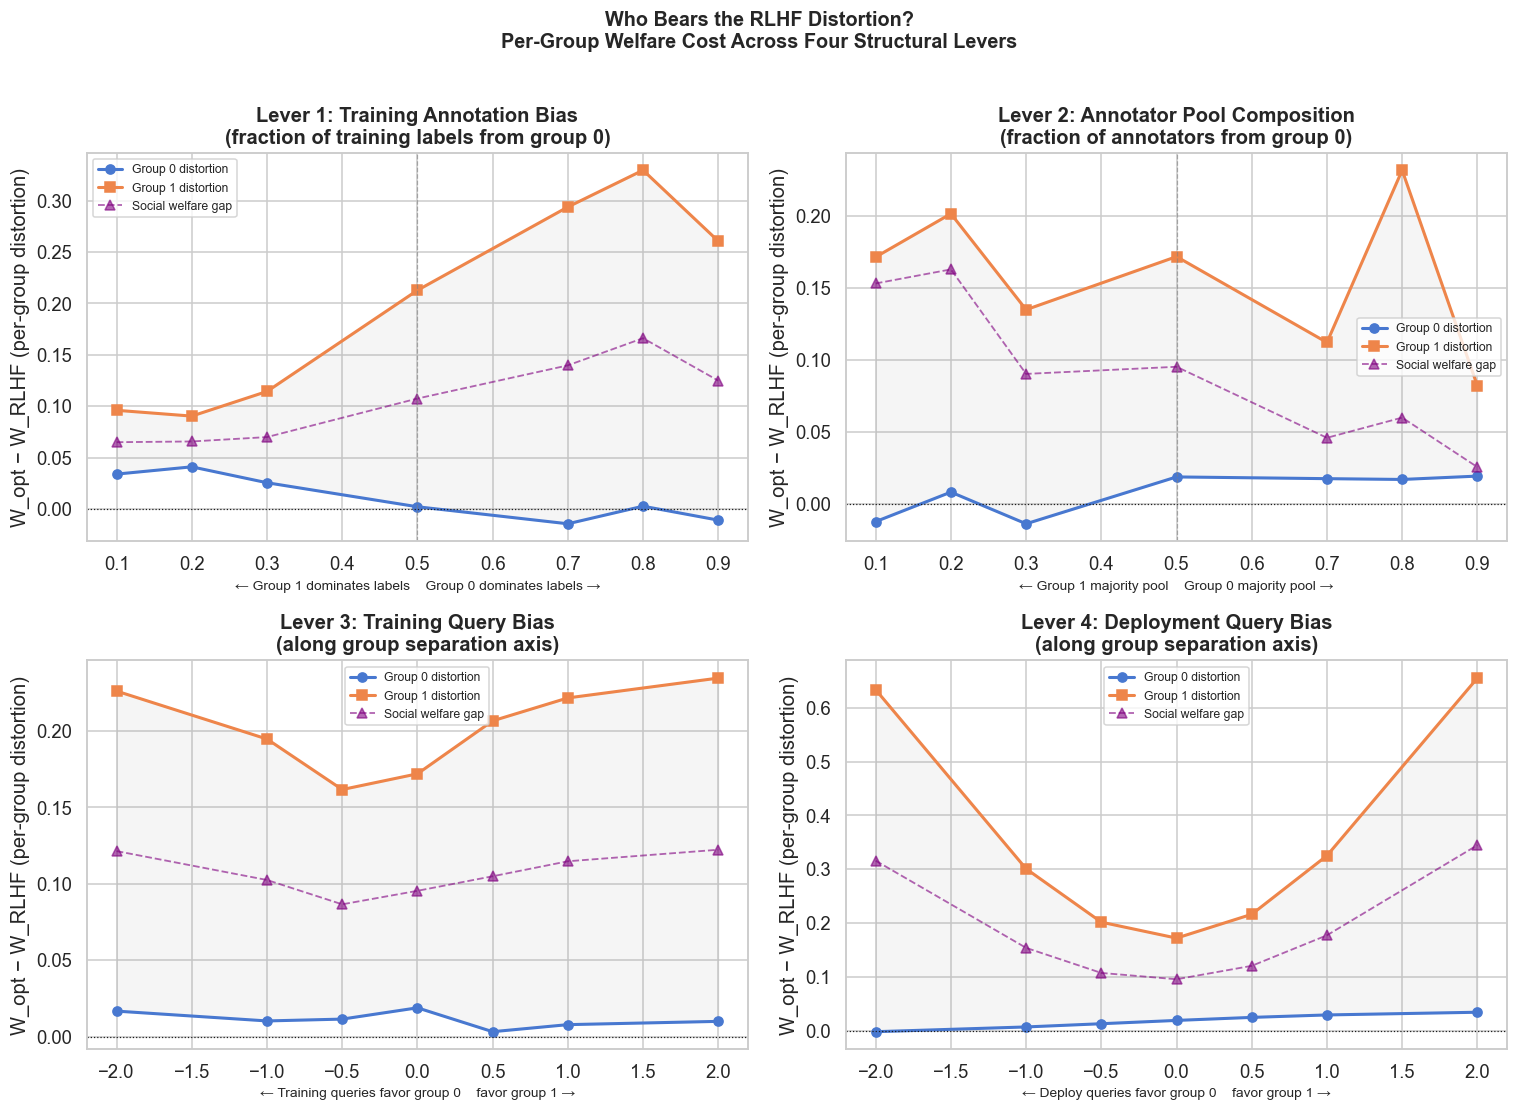

In [135]:
print("Running 4-lever sweeps... (~90s)")
df_annot   = sweep_annotation_bias()
df_pool    = sweep_pool_composition()
df_trbias  = sweep_train_query_bias()
df_depbias = sweep_deploy_query_bias()
print("Done.")

# ── Who Bears the Distortion? 2×2 panel ──────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

c0, c1, csw = colors[0], colors[1], 'purple'

panels = [
    (df_annot,   "group0_train_frac",
     "← Group 1 dominates labels    Group 0 dominates labels →",
     "Lever 1: Training Annotation Bias\n(fraction of training labels from group 0)"),

    (df_pool,    "group0_pool_frac",
     "← Group 1 majority pool    Group 0 majority pool →",
     "Lever 2: Annotator Pool Composition\n(fraction of annotators from group 0)"),

    (df_trbias,  "train_query_bias",
     "← Training queries favor group 0    favor group 1 →",
     "Lever 3: Training Query Bias\n(along group separation axis)"),

    (df_depbias, "deploy_query_bias",
     "← Deploy queries favor group 0    favor group 1 →",
     "Lever 4: Deployment Query Bias\n(along group separation axis)"),
]

for ax, (df, xcol, xlabel, title) in zip(axes.ravel(), panels):
    x = df[xcol]
    ax.plot(x, df["distortion_g0"], 'o-', color=c0, linewidth=2, label="Group 0 distortion")
    ax.plot(x, df["distortion_g1"], 's-', color=c1, linewidth=2, label="Group 1 distortion")
    ax.plot(x, df["sw_gap"],        '^--', color=csw, linewidth=1.2, alpha=0.6,
            label="Social welfare gap")
    ax.fill_between(x, df["distortion_g0"], df["distortion_g1"],
                    alpha=0.08, color='gray')
    ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
    if xcol in ("group0_train_frac", "group0_pool_frac"):
        ax.axvline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("W_opt − W_RLHF (per-group distortion)")
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle("Who Bears the RLHF Distortion?\nPer-Group Welfare Cost Across Four Structural Levers",
             fontweight='bold', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Heterogeneity and Distortion

**Question:** Holding group sizes and annotation fractions equal (50/50), how does
group 1's *preference distribution shape* affect their RLHF distortion?

Two distinct sources of heterogeneity:

- **Spread** (`cov_delta`): how much more internally diverse group 1 is compared to group 0.
  When group 1 agents disagree more among themselves, their training labels partially cancel
  out in the pooled logistic regression — effectively reducing their influence on θ̂ even with
  equal label counts. Group 0, being more homogeneous, punches above its weight.

- **Mean offset** (`mean_separation`): how far group 1's preference centroid is from group 0's.
  This controls how much the groups *disagree on average*, independent of within-group spread.

We sweep each independently, then show their joint effect as a heatmap.

In [136]:
def _heterogeneity_base():
    """Equal groups, equal annotation, isotropic queries — only heterogeneity varies."""
    return dict(n_agents=50, k_dim=8, n_train_queries=1000, n_deploy_queries=200,
                n_groups=2, train_group_fracs=None, group_sizes=None,
                train_query_mean=None, deploy_query_mean=None)


def sweep_spread(cov_deltas=None, mean_separation=1.5, n_seeds=5) -> pd.DataFrame:
    """
    Sweep group 1's spread (cov_delta) at fixed mean offset.
    cov_delta=0 → both groups have same scale (only orientation differs).
    cov_delta=2 → group 1 has 3x the spread of group 0.
    Averaged over multiple seeds to reduce noise from random covariance draws.
    """
    cov_deltas = cov_deltas or [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
    records = []
    for cd in cov_deltas:
        d0s, d1s = [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_heterogeneity_base(),
                            mean_separation=mean_separation, cov_delta=cd, seed=seed)
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            d0s.append(wdf[wdf.group == 0]["rlhf_distortion"].mean())
            d1s.append(wdf[wdf.group == 1]["rlhf_distortion"].mean())
        records.append({
            "cov_delta":    cd,
            "spread_ratio": 1 + cd,
            "distortion_g0_mean": np.mean(d0s),
            "distortion_g0_se":   np.std(d0s) / np.sqrt(n_seeds),
            "distortion_g1_mean": np.mean(d1s),
            "distortion_g1_se":   np.std(d1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


def sweep_mean_offset(separations=None, cov_delta=0.0, n_seeds=5) -> pd.DataFrame:
    """
    Sweep mean offset (mean_separation) at fixed equal spread (cov_delta=0).
    Isolates the effect of group disagreement without spread confound.
    """
    separations = separations or [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0]
    records = []
    for sep in separations:
        d0s, d1s = [], []
        for seed in range(n_seeds):
            cfg = DGPConfig(**_heterogeneity_base(),
                            mean_separation=sep, cov_delta=cov_delta, seed=seed)
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            d0s.append(wdf[wdf.group == 0]["rlhf_distortion"].mean())
            d1s.append(wdf[wdf.group == 1]["rlhf_distortion"].mean())
        records.append({
            "mean_separation": sep,
            "distortion_g0_mean": np.mean(d0s),
            "distortion_g0_se":   np.std(d0s) / np.sqrt(n_seeds),
            "distortion_g1_mean": np.mean(d1s),
            "distortion_g1_se":   np.std(d1s) / np.sqrt(n_seeds),
        })
    return pd.DataFrame(records)


def heatmap_spread_vs_offset(cov_deltas=None, separations=None, seed=0) -> pd.DataFrame:
    """2D grid: cov_delta × mean_separation → group 1 distortion."""
    cov_deltas  = cov_deltas  or [0.0, 0.5, 1.0, 2.0, 3.0]
    separations = separations or [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
    records = []
    for cd in cov_deltas:
        for sep in separations:
            cfg = DGPConfig(**_heterogeneity_base(),
                            mean_separation=sep, cov_delta=cd, seed=seed)
            res = Experiment(cfg).run()
            wdf = res["welfare_df"]
            records.append({
                "cov_delta":       cd,
                "mean_separation": sep,
                "distortion_g1":   wdf[wdf.group == 1]["rlhf_distortion"].mean(),
                "distortion_g0":   wdf[wdf.group == 0]["rlhf_distortion"].mean(),
                "sw_gap":          res["sw_gap"],
            })
    return pd.DataFrame(records)


print("Running heterogeneity sweeps...")
df_spread = sweep_spread(n_seeds=8)
df_offset = sweep_mean_offset(n_seeds=8)
df_heat   = heatmap_spread_vs_offset()
print("Done.")

Running heterogeneity sweeps...
Done.


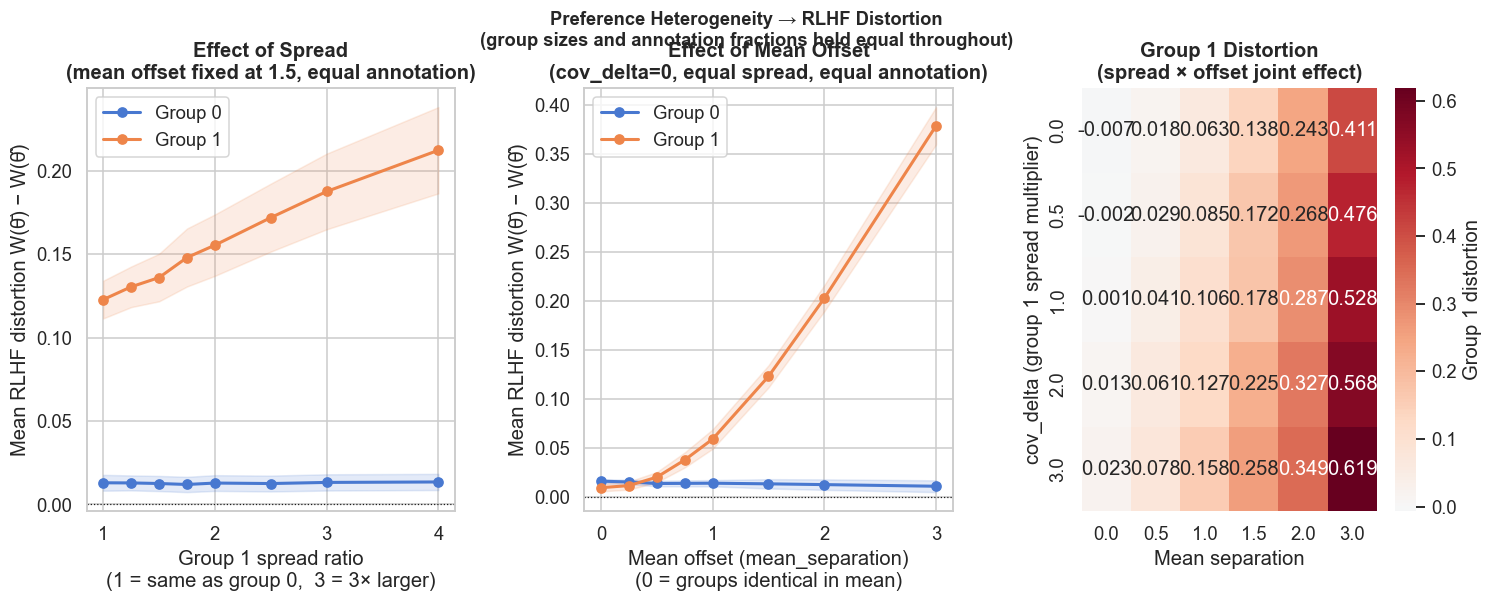


Spread sweep (cov_delta, group 1 distortion mean ± SE):
 spread_ratio  distortion_g1_mean  distortion_g1_se  distortion_g0_mean
         1.00              0.1227            0.0113              0.0130
         1.25              0.1304            0.0122              0.0129
         1.50              0.1359            0.0142              0.0126
         1.75              0.1479            0.0174              0.0120
         2.00              0.1553            0.0184              0.0128
         2.50              0.1718            0.0204              0.0125
         3.00              0.1875            0.0227              0.0132
         4.00              0.2122            0.0258              0.0135

Mean offset sweep (group 1 distortion mean ± SE):
 mean_separation  distortion_g1_mean  distortion_g1_se  distortion_g0_mean
            0.00              0.0091            0.0037              0.0157
            0.25              0.0112            0.0041              0.0149
            0.50   

In [137]:
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

# ── Panel 1: Spread sweep ─────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
x = df_spread["spread_ratio"]   # 1 + cov_delta, more interpretable than cov_delta itself

for g, (col, label) in enumerate([(colors[0], "Group 0"), (colors[1], "Group 1")]):
    mean_col = f"distortion_g{g}_mean"
    se_col   = f"distortion_g{g}_se"
    ax1.plot(x, df_spread[mean_col], 'o-', color=col, linewidth=2, label=label)
    ax1.fill_between(x,
                     df_spread[mean_col] - df_spread[se_col],
                     df_spread[mean_col] + df_spread[se_col],
                     alpha=0.15, color=col)

ax1.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax1.set_xlabel("Group 1 spread ratio\n(1 = same as group 0,  3 = 3× larger)")
ax1.set_ylabel("Mean RLHF distortion W(θ̄) − W(θ̂)")
ax1.set_title("Effect of Spread\n(mean offset fixed at 1.5, equal annotation)",
              fontweight='bold')
ax1.legend()

# ── Panel 2: Mean offset sweep ────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
x2  = df_offset["mean_separation"]

for g, (col, label) in enumerate([(colors[0], "Group 0"), (colors[1], "Group 1")]):
    mean_col = f"distortion_g{g}_mean"
    se_col   = f"distortion_g{g}_se"
    ax2.plot(x2, df_offset[mean_col], 'o-', color=col, linewidth=2, label=label)
    ax2.fill_between(x2,
                     df_offset[mean_col] - df_offset[se_col],
                     df_offset[mean_col] + df_offset[se_col],
                     alpha=0.15, color=col)

ax2.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax2.set_xlabel("Mean offset (mean_separation)\n(0 = groups identical in mean)")
ax2.set_ylabel("Mean RLHF distortion W(θ̄) − W(θ̂)")
ax2.set_title("Effect of Mean Offset\n(cov_delta=0, equal spread, equal annotation)",
              fontweight='bold')
ax2.legend()

# ── Panel 3: Heatmap — joint effect ──────────────────────────────────────
ax3 = fig.add_subplot(gs[2])
pivot = df_heat.pivot(index="cov_delta", columns="mean_separation", values="distortion_g1")
sns.heatmap(pivot, ax=ax3, cmap="RdBu_r", center=0, annot=True, fmt=".3f",
            cbar_kws={"label": "Group 1 distortion"})
ax3.set_xlabel("Mean separation")
ax3.set_ylabel("cov_delta (group 1 spread multiplier)")
ax3.set_title("Group 1 Distortion\n(spread × offset joint effect)",
              fontweight='bold')

plt.suptitle("Preference Heterogeneity → RLHF Distortion\n"
             "(group sizes and annotation fractions held equal throughout)",
             fontweight='bold', fontsize=12, y=1.02)
plt.show()

print("\nSpread sweep (cov_delta, group 1 distortion mean ± SE):")
print(df_spread[["spread_ratio","distortion_g1_mean","distortion_g1_se",
                  "distortion_g0_mean"]].round(4).to_string(index=False))
print("\nMean offset sweep (group 1 distortion mean ± SE):")
print(df_offset[["mean_separation","distortion_g1_mean","distortion_g1_se",
                  "distortion_g0_mean"]].round(4).to_string(index=False))

---
## 10. Sweeping Group Disagreement: 0 → k Opposed Dimensions

Fix equal groups, equal annotation, equal spread (`cov_delta=0`). Vary how many
dimensions are *opposed* (group 0 positive, group 1 negative) vs *aligned* (both positive).

**Key quantities to watch:**
- `rlhf_distortion` = W(θ̄) − W(θ̂): extra cost from RLHF vs. utilitarian optimum
- `delegation_loss` = W* − W(θ̄): unavoidable cost of delegating to *any* model
- `total_loss` = W* − W(θ̂): full welfare cost

At **0 opposed dims** (fully aligned): both groups want the same things — θ̄ is large and
shared, delegation loss is low, distortion is low.

At **k opposed dims** (fully opposed): θ̄ ≈ 0 (groups cancel). Both groups suffer
high delegation loss. But θ̂ ≈ θ̄ ≈ 0, so *distortion stays low* — RLHF finds
the utilitarian answer, it's just that the utilitarian answer is bad for everyone.

In [ ]:
def sweep_disagreement(k=8, mean_magnitude=1.5, n_seeds=8) -> pd.DataFrame:
    """
    Sweep number of opposed dimensions from 0 (fully aligned) to k (fully opposed).
    First n_opp dims are opposed (-1), remaining are aligned (+1).
    Averaged over n_seeds to reduce orientation noise.
    """
    records = []
    for n_opp in range(k + 1):
        agreement = np.array([-1]*n_opp + [+1]*(k - n_opp), dtype=float)
        rows = {col: [] for col in [
            'distortion_g0', 'distortion_g1',
            'delegation_g0', 'delegation_g1',
            'total_loss_g0', 'total_loss_g1',
            'sw_gap', 'theta_dist',
        ]}
        for seed in range(n_seeds):
            cfg = DGPConfig(
                n_agents=50, k_dim=k,
                n_train_queries=1000, n_deploy_queries=200,
                n_groups=2,
                mean_magnitude=mean_magnitude,
                dim_agreement=agreement,
                cov_delta=0.0,
                seed=seed,
            )
            res = Experiment(cfg).run()
            wdf = res['welfare_df']
            for g in range(2):
                gdf = wdf[wdf.group == g]
                rows[f'distortion_g{g}'].append(gdf['rlhf_distortion'].mean())
                rows[f'delegation_g{g}'].append(gdf['delegation_loss'].mean())
                rows[f'total_loss_g{g}'].append(gdf['total_loss'].mean())
            rows['sw_gap'].append(res['sw_gap'])
            rows['theta_dist'].append(res['theta_dist'])

        records.append({
            'n_opposed':    n_opp,
            'frac_opposed': n_opp / k,
            **{col: np.mean(vals) for col, vals in rows.items()},
            **{col + '_se': np.std(vals) / np.sqrt(n_seeds) for col, vals in rows.items()},
        })
    return pd.DataFrame(records)


print("Running disagreement sweep...")
df_disagree = sweep_disagreement(k=8, n_seeds=8)
print("Done.")
print(df_disagree[['n_opposed','distortion_g0','distortion_g1',
                    'delegation_g0','delegation_g1','sw_gap']].round(4).to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
x  = df_disagree['n_opposed']
c0, c1 = colors[0], colors[1]

# ── Panel 1: RLHF distortion ──────────────────────────────────────────────
ax = axes[0]
for g, (col, label) in enumerate([(c0, 'Group 0'), (c1, 'Group 1')]):
    m, se = df_disagree[f'distortion_g{g}'], df_disagree[f'distortion_g{g}_se']
    ax.plot(x, m, 'o-', color=col, linewidth=2, label=label)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=col)
ax.plot(x, df_disagree['sw_gap'], '^--', color='purple', alpha=0.7,
        linewidth=1.5, label='Social welfare gap')
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.text(4.1, ax.get_ylim()[1] * 0.9, 'half/half', fontsize=8, color='gray')
ax.set_xlabel('Number of opposed dimensions (out of 8)')
ax.set_ylabel('W(θ̄) − W(θ̂)')
ax.set_title('RLHF Distortion\nvs. Utilitarian Optimum', fontweight='bold')
ax.set_xticks(range(9))
ax.legend(fontsize=9)

# ── Panel 2: Delegation loss ──────────────────────────────────────────────
ax = axes[1]
for g, (col, label) in enumerate([(c0, 'Group 0'), (c1, 'Group 1')]):
    m, se = df_disagree[f'delegation_g{g}'], df_disagree[f'delegation_g{g}_se']
    ax.plot(x, m, 'o-', color=col, linewidth=2, label=label)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=col)
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Number of opposed dimensions (out of 8)')
ax.set_ylabel('W*(θ_n) − W(θ̄)')
ax.set_title('Delegation Loss\n(unavoidable cost of any model)', fontweight='bold')
ax.set_xticks(range(9))
ax.legend(fontsize=9)

# ── Panel 3: Total loss ───────────────────────────────────────────────────
ax = axes[2]
for g, (col, label) in enumerate([(c0, 'Group 0'), (c1, 'Group 1')]):
    m, se = df_disagree[f'total_loss_g{g}'], df_disagree[f'total_loss_g{g}_se']
    ax.plot(x, m, 'o-', color=col, linewidth=2, label=label)
    ax.fill_between(x, m - se, m + se, alpha=0.15, color=col)
ax.axhline(0, color='k', linewidth=0.8, linestyle=':')
ax.axvline(4, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Number of opposed dimensions (out of 8)')
ax.set_ylabel('W*(θ_n) − W(θ̂)')
ax.set_title('Total Welfare Loss\n(distortion + delegation)', fontweight='bold')
ax.set_xticks(range(9))
ax.legend(fontsize=9)

plt.suptitle('Effect of Group Disagreement on Welfare Losses\n'
             '(equal groups, equal annotation, cov_delta=0)',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Discussion

### What these simulations demonstrate

| Result | Interpretation |
|--------|----------------|
| $\hat{\theta}^{\text{RLHF}} \neq \bar{\theta}$ | Anonymous RLHF does not recover the utilitarian preference |
| SW gap grows with mean separation | More diverse preferences → more distortion |
| SW gap doesn't vanish with $N$ | Adding more annotators doesn't fix the systematic bias |
| Avg externality $\approx 0$ | Proposition 1 holds numerically |
| IF ≈ LOO | Influence function is a reliable cheap proxy |
| Minority distortion varies nonlinearly | Upweighting a minority can hurt them if RLHF is still mis-targeted |

### Next steps
1. **Real preference data**: Swap in human preference datasets (e.g., Anthropic HH, OpenAI summarization) as $\theta_n$ by fitting per-annotator logit models.
2. **Non-uniform deployment $q_\text{dep}$**: Test mismatch between training query distribution and real-world usage.
3. **Individual-conditioned RLHF**: Implement $\hat{\theta}^{\text{cond}}_{n,z}$ (conditioning on annotator identity) and show reduced distortion.
4. **Query reweighting**: Per Proposition 3, test whether changing $q_\text{train}$ (who labels which queries) can recover Pareto-efficient parameters.
5. **More groups**: Test $G > 2$ groups with different sizes and covariance structures.
